In [1]:
# import các thư viện cần thiết
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)
from sklearn.model_selection import train_test_split

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df = pd.read_csv('/content/drive/MyDrive/HocHanh/Level 3/Final Project/INSURANCE.csv')

In [4]:
df.head()

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,1,Male,44,1,28.0,0,> 2 Years,Yes,40454.0,26.0,217,1
1,2,Male,76,1,3.0,0,1-2 Year,No,33536.0,26.0,183,0
2,3,Male,47,1,28.0,0,> 2 Years,Yes,38294.0,26.0,27,1
3,4,Male,21,1,11.0,1,< 1 Year,No,28619.0,152.0,203,0
4,5,Female,29,1,41.0,1,< 1 Year,No,27496.0,152.0,39,0


In [5]:
df.shape

(381109, 12)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 381109 entries, 0 to 381108
Data columns (total 12 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    381109 non-null  int64  
 1   Gender                381109 non-null  object 
 2   Age                   381109 non-null  int64  
 3   Driving_License       381109 non-null  int64  
 4   Region_Code           381109 non-null  float64
 5   Previously_Insured    381109 non-null  int64  
 6   Vehicle_Age           381109 non-null  object 
 7   Vehicle_Damage        381109 non-null  object 
 8   Annual_Premium        381109 non-null  float64
 9   Policy_Sales_Channel  381109 non-null  float64
 10  Vintage               381109 non-null  int64  
 11  Response              381109 non-null  int64  
dtypes: float64(3), int64(6), object(3)
memory usage: 34.9+ MB


In [7]:
df['Vehicle_Age'].unique()

array(['> 2 Years', '1-2 Year', '< 1 Year'], dtype=object)

In [8]:
df['Policy_Sales_Channel'].unique()

array([ 26., 152., 160., 124.,  14.,  13.,  30., 156., 163., 157., 122.,
        19.,  22.,  15., 154.,  16.,  52., 155.,  11., 151., 125.,  25.,
        61.,   1.,  86.,  31., 150.,  23.,  60.,  21., 121.,   3., 139.,
        12.,  29.,  55.,   7.,  47., 127., 153.,  78., 158.,  89.,  32.,
         8.,  10., 120.,  65.,   4.,  42.,  83., 136.,  24.,  18.,  56.,
        48., 106.,  54.,  93., 116.,  91.,  45.,   9., 145., 147.,  44.,
       109.,  37., 140., 107., 128., 131., 114., 118., 159., 119., 105.,
       135.,  62., 138., 129.,  88.,  92., 111., 113.,  73.,  36.,  28.,
        35.,  59.,  53., 148., 133., 108.,  64.,  39.,  94., 132.,  46.,
        81., 103.,  90.,  51.,  27., 146.,  63.,  96.,  40.,  66., 100.,
        95., 123.,  98.,  75.,  69., 130., 134.,  49.,  97.,  38.,  17.,
       110.,  80.,  71., 117.,  58.,  20.,  76., 104.,  87.,  84., 137.,
       126.,  68.,  67., 101., 115.,  57.,  82.,  79., 112.,  99.,  70.,
         2.,  34.,  33.,  74., 102., 149.,  43.,   

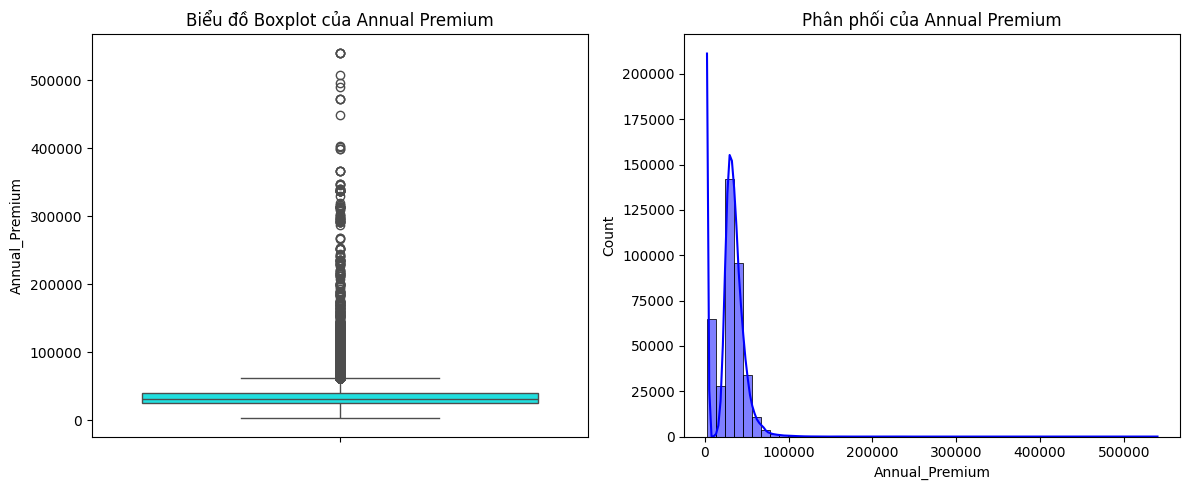

In [9]:
# Vẽ biểu đồ Boxplot
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(y=df['Annual_Premium'], color='cyan')
plt.title('Biểu đồ Boxplot của Annual Premium')

# Vẽ biểu đồ Histogram để xem phân phối có bị lệch không
plt.subplot(1, 2, 2)
sns.histplot(df['Annual_Premium'], bins=50, kde=True, color='blue')
plt.title('Phân phối của Annual Premium')

plt.tight_layout()
plt.show()

In [10]:
# Label Encoding Gender
df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})

# Xử lý Vehicle_Age
# Vì độ tuổi xe có tính thứ tự: < 1 năm < 1-2 năm < > 2 năm
age_mapping = {'< 1 Year': 0, '1-2 Year': 1, '> 2 Years': 2}
df['Vehicle_Age'] = df['Vehicle_Age'].map(age_mapping)

# Đưa Vehicle_Damage về dạng 0, 1
# Yes (Có hư hỏng) = 1, No (Không) = 0
df['Vehicle_Damage'] = df['Vehicle_Damage'].map({'Yes': 1, 'No': 0})

# Kiểm tra lại kết quả
print(df[['Gender', 'Vehicle_Age', 'Vehicle_Damage']].head())

   Gender  Vehicle_Age  Vehicle_Damage
0       1            2               1
1       1            1               0
2       1            2               1
3       1            0               0
4       0            0               0


In [11]:
# Xem tương quan của các cột với biến Response
correlations = df.corr()['Response'].sort_values(ascending=False)

print("TƯƠNG QUAN VỚI BIẾN RESPONSE")
print(correlations)

TƯƠNG QUAN VỚI BIẾN RESPONSE
Response                1.000000
Vehicle_Damage          0.354400
Vehicle_Age             0.221874
Age                     0.111147
Gender                  0.052440
Annual_Premium          0.022575
Region_Code             0.010570
Driving_License         0.010155
Vintage                -0.001050
id                     -0.001368
Policy_Sales_Channel   -0.139042
Previously_Insured     -0.341170
Name: Response, dtype: float64


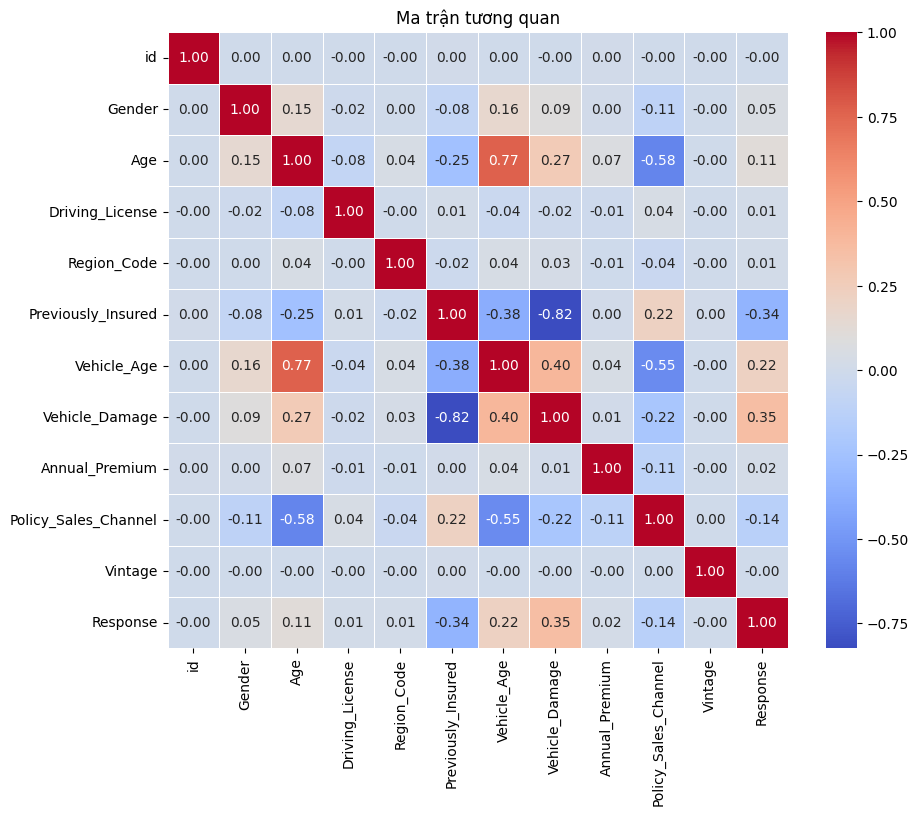

In [12]:
plt.figure(figsize=(10, 8))
# Vẽ Heatmap
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)

plt.title('Ma trận tương quan')
plt.show()

Age và Vehicle_Age (0.77): Có tương quan khá mạnh. Chủ xe càng lớn tuổi thì thường có xu hướng sở hữu xe lâu hơn hoặc sử dụng các dòng xe nhất định. giữ lại Age, ko giữ Vehicle_Age

Tuổi của chủ xe giúp công ty phân loại phân khúc khách hàng (Customer Segmentation) tốt hơn.

Ví dụ: Nhóm khách hàng trẻ thường rủi ro khác hẳn nhóm trung niên. Vehicle_Age chỉ cho biết chiếc xe cũ hay mới, nhưng không cho biết tâm lý của người lái.
Age ở dạng số giúp các mô hình học máy dễ dàng tìm ra các mối quan hệ phi tuyến tính phức tạp hơn. Nếu giữ Age, vẫn có thể đoán được phần nào tình trạng xe, nhưng nếu chỉ giữ Vehicle_Age, sẽ mất hoàn toàn thông tin về độ tuổi người dùng.

Previously_Insured và Vehicle_Damage (-0.82): Đây là tương quan nghịch rất mạnh. Những người đã có bảo hiểm thường ít để xảy ra hư hại xe (hoặc ngược lại). Vehicle_Damage (0.35) có tương quan với Response cao hơn so với Previously_Insured (-0.34), nên giữ Vehicle_Damage.
Một lý do khác để giữ Vehicle_Damage là vì nó phản ánh trực tiếp rủi ro của khách hàng. Người đã từng va chạm xe (Vehicle_Damage = Yes) thường có nhu cầu mua bảo hiểm cao hơn hẳn những người khác

In [13]:
# Chọn X (biến độc lập) và y (biến mục tiêu)
X = df[['Age', 'Vehicle_Damage', 'Annual_Premium', 'Policy_Sales_Channel']]
y = df['Response']

In [14]:
# Chia Train - Test (Tỉ lệ 80/20)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [15]:
# Scaling (Chỉ nên Fit trên X_train để tránh rò rỉ dữ liệu)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [16]:
import pandas as pd

# Chuyển đổi ngược lại thành DataFrame
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)

# Chỉ chọn 2 cột Age và Annual_Premium để xem
cols_to_show = ['Age', 'Annual_Premium']

print("Dữ liệu sau khi chuẩn hóa:")
display(X_train_scaled_df[cols_to_show].head())

# Kiểm tra nhanh Mean và Std của riêng 2 cột này
print("\nKiểm tra Mean và Std (Cần Mean ~ 0 và Std ~ 1):")
print(X_train_scaled_df[cols_to_show].describe().loc[['mean', 'std']].round(2))

Dữ liệu sau khi chuẩn hóa:


,Age,Annual_Premium
0,0.010601,1.294417
1,-0.053875,-0.436638
2,-1.085502,0.854640
3,-1.021025,-0.083449
4,1.106704,-1.619422



Kiểm tra Mean và Std (Cần Mean ~ 0 và Std ~ 1):
      Age  Annual_Premium
mean -0.0            -0.0
std   1.0             1.0


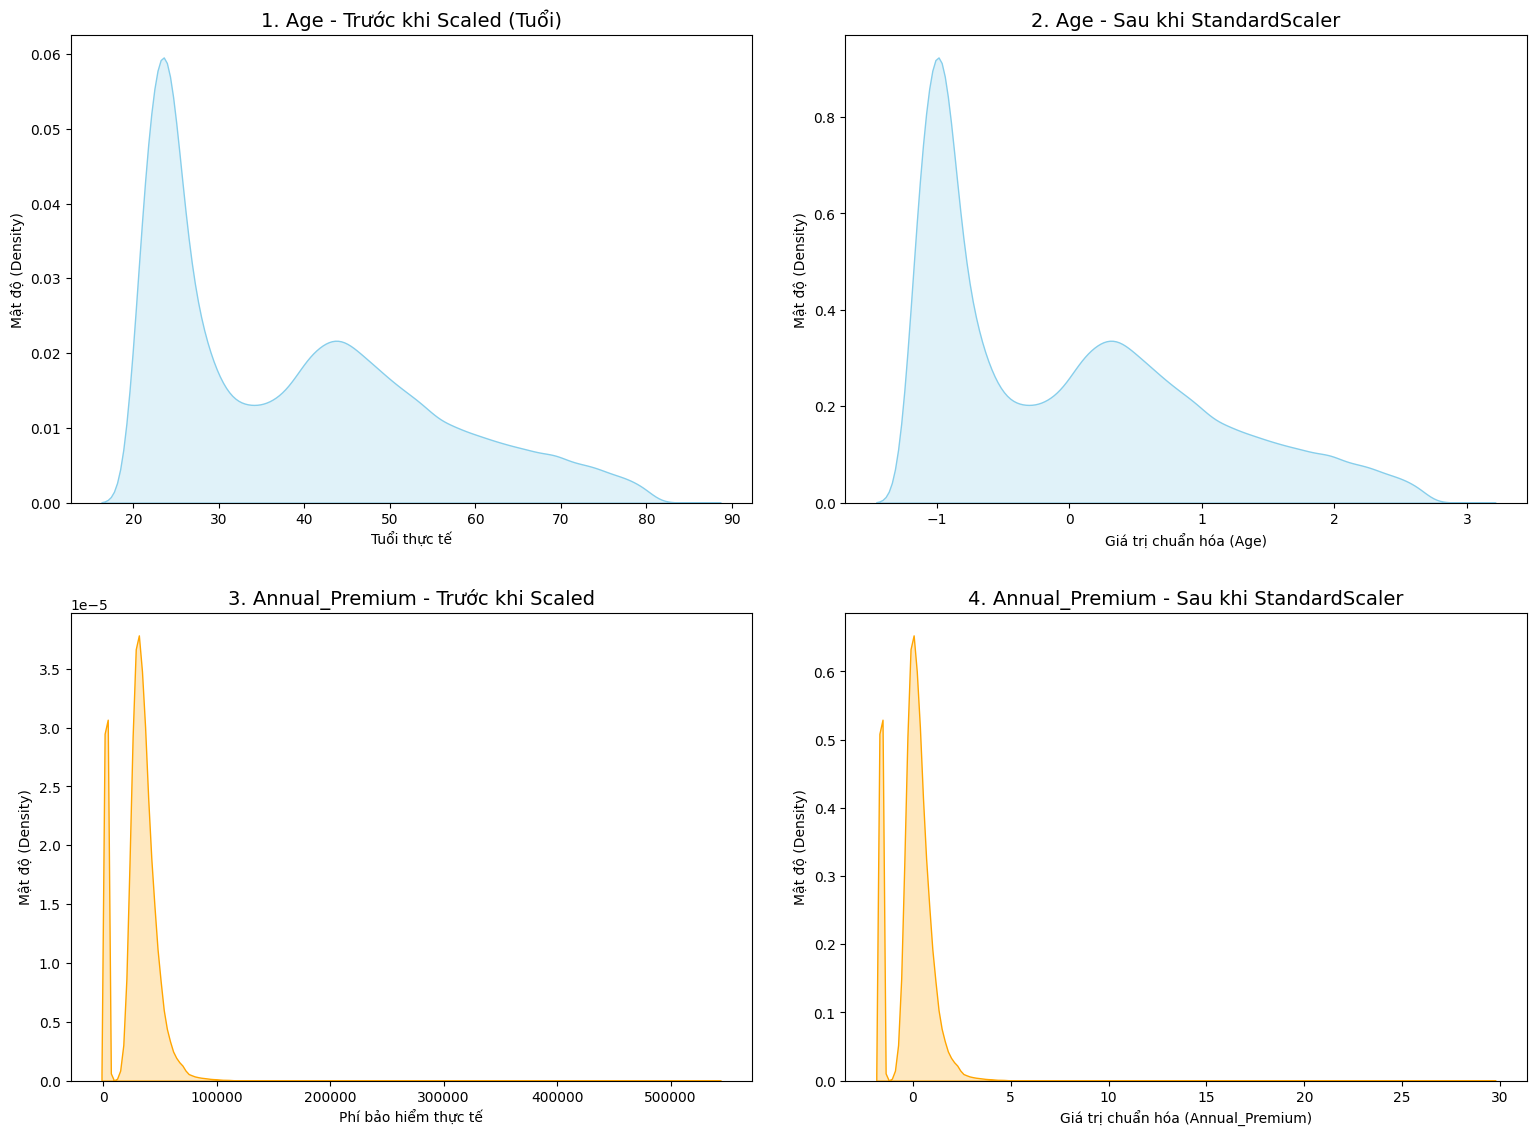

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Thiết kế khung hình: 2 hàng, 2 cột (Tổng 4 hình)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Màu sắc
colors = {'Age': 'skyblue', 'Annual_Premium': 'orange'}

# HÀNG 1: BIẾN "AGE"

# Age - Trước khi Scaled
sns.kdeplot(X_train['Age'], color=colors['Age'], fill=True, ax=axes[0, 0])
axes[0, 0].set_title('1. Age - Trước khi Scaled (Tuổi)', fontsize=14)
axes[0, 0].set_xlabel('Tuổi thực tế')
axes[0, 0].set_ylabel('Mật độ (Density)')

# Age - Sau khi Scaled
sns.kdeplot(X_train_scaled_df['Age'], color=colors['Age'], fill=True, ax=axes[0, 1])
axes[0, 1].set_title('2. Age - Sau khi StandardScaler', fontsize=14)
axes[0, 1].set_xlabel('Giá trị chuẩn hóa (Age)')
axes[0, 1].set_ylabel('Mật độ (Density)')


# HÀNG 2: BIẾN "ANNUAL_PREMIUM" (PHÍ BẢO HIỂM)

# Annual_Premium - Trước khi Scaled
sns.kdeplot(X_train['Annual_Premium'], color=colors['Annual_Premium'], fill=True, ax=axes[1, 0])
axes[1, 0].set_title('3. Annual_Premium - Trước khi Scaled', fontsize=14)
axes[1, 0].set_xlabel('Phí bảo hiểm thực tế')
axes[1, 0].set_ylabel('Mật độ (Density)')

# Annual_Premium - Sau khi Scaled
sns.kdeplot(X_train_scaled_df['Annual_Premium'], color=colors['Annual_Premium'], fill=True, ax=axes[1, 1])
axes[1, 1].set_title('4. Annual_Premium - Sau khi StandardScaler', fontsize=14)
axes[1, 1].set_xlabel('Giá trị chuẩn hóa (Annual_Premium)')
axes[1, 1].set_ylabel('Mật độ (Density)')

# Tinh chỉnh khoảng cách giữa các hình
plt.tight_layout(pad=3.0)
plt.show()

/tmp/ipykernel_5336/605322351.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train, palette='viridis')


Text(0.5, 1.0, 'Trước khi SMOTE (Imbalanced)')

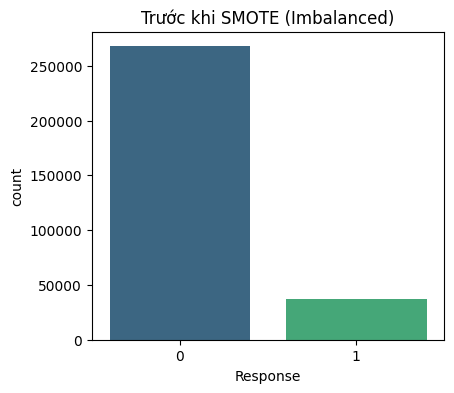

In [18]:
# Vẽ biểu đồ
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.countplot(x=y_train, palette='viridis')
plt.title('Trước khi SMOTE (Imbalanced)')


/tmp/ipykernel_5336/658482746.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train_res, palette='magma')


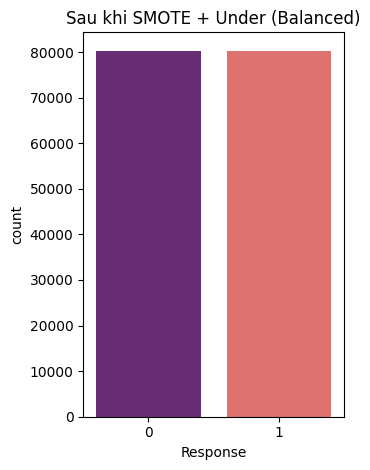

Số lượng mẫu sau khi cân bằng:
Response
0    80310
1    80310
Name: count, dtype: int64


In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline

# Thiết lập Pipeline để cân bằng
# Bước 1: SMOTE để tăng nhóm 1 lên
# Bước 2: UnderSampling nhóm 0 xuống để bằng nhóm 1 (tỷ lệ 1:1)
over = SMOTE(sampling_strategy=0.3, random_state=42)
under = RandomUnderSampler(sampling_strategy=1.0, random_state=42)

steps = [('o', over), ('u', under)]
pipeline = Pipeline(steps=steps)

# Thực hiện cân bằng trên tập TRAIN
X_train_res, y_train_res = pipeline.fit_resample(X_train_scaled, y_train)

# Vẽ biểu đồ sau khi cân bằng
plt.subplot(1, 2, 2)
sns.countplot(x=y_train_res, palette='magma')
plt.title('Sau khi SMOTE + Under (Balanced)')

plt.tight_layout()
plt.show()

# In kết quả kiểm chứng
print("Số lượng mẫu sau khi cân bằng:")
print(pd.Series(y_train_res).value_counts())

Fitting 3 folds for each of 10 candidates, totalling 30 fits

THÔNG SỐ TỐI ƯU NHẤT TÌM ĐƯỢC:
{'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_depth': 20, 'bootstrap': True}
KẾT QUẢ MÔ HÌNH RANDOM FOREST
              precision    recall  f1-score   support

           0       0.97      0.70      0.81     66699
           1       0.29      0.86      0.43      9523

    accuracy                           0.72     76222
   macro avg       0.63      0.78      0.62     76222
weighted avg       0.89      0.72      0.77     76222

ROC-AUC Score: 0.8379


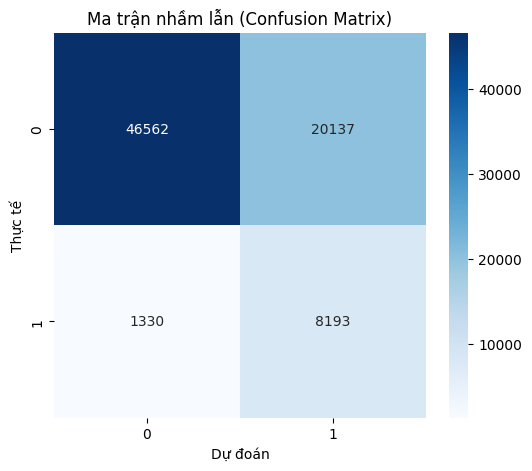

In [20]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

# Khởi tạo mô hình
rf = RandomForestClassifier(random_state=42)

# Cấu hình RandomizedSearch
rf_random = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=10,
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1,
    scoring='f1'
)

# Chạy quá trình tìm kiếm thông số tối ưu
rf_random.fit(X_train_res, y_train_res)

# Lấy ra bộ thông số tốt nhất
best_params = rf_random.best_params_
print("\nTHÔNG SỐ TỐI ƯU NHẤT TÌM ĐƯỢC:")
print(best_params)

# Sử dụng mô hình tốt nhất để dự đoán
rf_model = rf_random.best_estimator_
y_pred = rf_model.predict(X_test_scaled)

y_proba = rf_model.predict_proba(X_test_scaled)[:, 1]

# In báo cáo kết quả
print("KẾT QUẢ MÔ HÌNH RANDOM FOREST")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba):.4f}")

# Vẽ Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Dự đoán')
plt.ylabel('Thực tế')
plt.title('Ma trận nhầm lẫn (Confusion Matrix)')
plt.show()

BẢNG XẾP HẠNG ĐỘ QUAN TRỌNG (GIẢM DẦN)
                Feature  Importance
1        Vehicle_Damage    0.576516
0                   Age    0.188565
2        Annual_Premium    0.119895
3  Policy_Sales_Channel    0.115024


/tmp/ipykernel_5336/2339668395.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


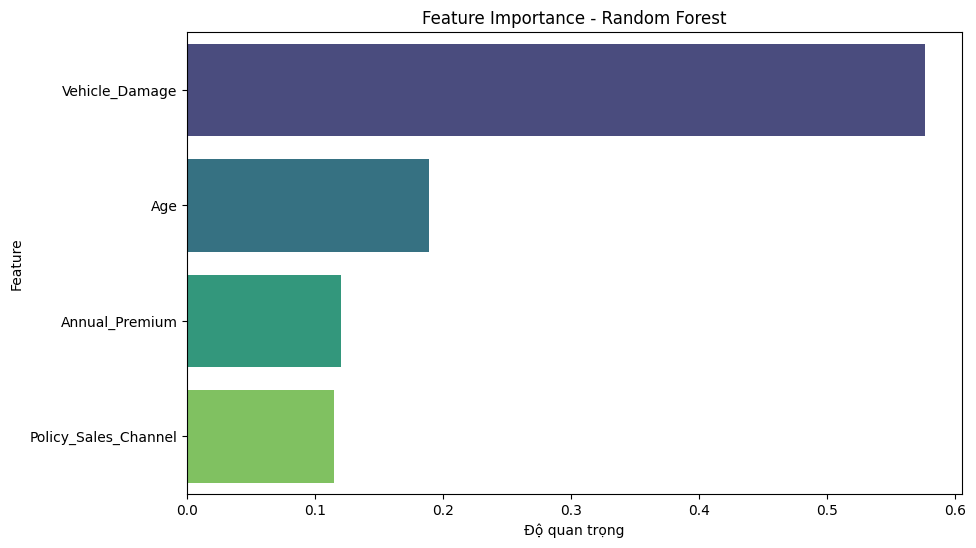

In [21]:
# Trích xuất độ quan trọng từ Random Forest
importances = rf_model.feature_importances_
feature_names = X.columns

# Tạo DataFrame
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# In ra bảng số liệu
print("BẢNG XẾP HẠNG ĐỘ QUAN TRỌNG (GIẢM DẦN)")
print(feature_importance_df)

# Vẽ biểu đồ cột ngang
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')

plt.title('Feature Importance - Random Forest')
plt.xlabel('Độ quan trọng')
plt.ylabel('Feature')
plt.show()

**1. Vehicle_Damage: Ngòi nổ của hành vi mua hàng**

Đây là biến quan trọng nhất.

Insight: Tiền sử tổn thất xe đóng vai trò là chất xúc tác tâm lý. Những khách hàng đã từng gặp rủi ro va chạm sẽ có mức độ nhạy cảm với rủi ro cao hơn hẳn. Họ hiểu rõ cảm giác mất mát tài chính đột ngột, từ đó dễ dàng chấp nhận các giải pháp bảo vệ sức khỏe như một lớp phòng thủ bổ sung.

Chiến lược: Đối với nhóm này, thông điệp Marketing không nên nói chung chung về sức khỏe, mà nên tập trung vào sự "An tâm toàn diện". Sử dụng hình ảnh "Bảo vệ tài sản đi đôi với bảo vệ con người" sẽ đánh trúng tâm lý của họ nhất.

**2. Age: Sự trưởng thành về nhận thức rủi ro**

Độ tuổi không chỉ là con số, nó đại diện cho giai đoạn cuộc đời.

Insight: Có một sự chuyển dịch rõ rệt về nhu cầu bảo hiểm theo độ tuổi.

Nhóm trẻ: Thường chủ quan về sức khỏe và ưu tiên ngân sách cho các nhu cầu tiêu dùng ngắn hạn.

Nhóm trung niên: Đây là "điểm rơi" lý tưởng. Họ bắt đầu có sự tích lũy tài chính, có gia đình phải gánh vác và bắt đầu cảm nhận được sự xuống dốc của sức khỏe.

Chiến lược: Tập trung khai thác nhóm khách hàng trung niên. Với nhóm này, bảo hiểm sức khỏe không phải là chi phí, mà là một khoản đầu tư cho gia đình.

**3. Policy_Sales_Channel: Hiệu quả của "Điểm chạm"**

Biến này cho thấy không phải kênh bán hàng nào cũng mang lại hiệu quả như nhau.

Insight: Việc chọn đúng kênh tiếp cận quyết định đến 50% sự thành công của thương vụ.

Các kênh có tính chất tương tác cao (như đại lý hoặc tư vấn trực tiếp) thường có tỷ lệ chuyển đổi tốt hơn do bảo hiểm là sản phẩm cần sự tin tưởng và giải thích kỹ lưỡng.

Các kênh số hóa có thể tiếp cận nhanh nhưng tỷ lệ chốt đơn thường thấp hơn nếu không có sự can thiệp của con người.

Chiến lược: Cần rà soát và phân bổ hoa hồng/ngân sách cao hơn cho những kênh bán hàng hoạt động hiệu quả. Đồng thời, chuẩn bị kịch bản riêng biệt cho từng kênh để tối ưu hóa trải nghiệm khách hàng.

**4. Annual_Premium: Phí bảo hiểm hàng năm**

Dù đứng thứ 4 trong danh sách nhưng Annual_Premium là nhân tố cực kỳ quan trọng về mặt định lượng để xác định "độ chịu chi" của khách hàng.

Phân tích: Mức phí bảo hiểm xe hiện tại phản ánh trực tiếp giá trị tài sản và khả năng tài chính của khách hàng. Những khách hàng đang đóng mức phí cao thường sở hữu xe đắt tiền hoặc các gói bảo hiểm toàn diện, chứng tỏ họ có tư duy bảo vệ tài sản rất tốt.

Chiến lược: Thiết kế gói sản phẩm: Với nhóm có phí bảo hiểm cao, không nên chào mời các gói Bảo hiểm giá rẻ. Thay vào đó, hãy tập trung vào các gói Bảo hiểm sức khỏe cao cấp với quyền lợi điều trị tại các bệnh viện quốc tế, tương xứng với đẳng cấp chi tiêu của họ.

In [22]:
# Lấy toàn bộ các cột từ df gốc, nhưng chỉ lấy các dòng dùng để test
df_viz = df.loc[X_test.index].copy()

# Chuyển Gender
df_viz['Gender'] = df_viz['Gender'].map({0: 'Female', 1: 'Male'})

# Chuyển Vehicle_Age
df_viz['Vehicle_Age'] = df_viz['Vehicle_Age'].map({0: '< 1 Year', 1: '1-2 Year', 2: '> 2 Years'})

# Chuyển Vehicle_Damage
df_viz['Vehicle_Damage'] = df_viz['Vehicle_Damage'].map({0: 'No', 1: 'Yes'})

# Kiểm tra lại 5 dòng đầu
print(df_viz[['Gender', 'Vehicle_Age', 'Vehicle_Damage']].head())

        Gender Vehicle_Age Vehicle_Damage
200222  Female    < 1 Year             No
49766     Male    1-2 Year            Yes
172201  Female    1-2 Year            Yes
160713  Female    < 1 Year             No
53272     Male    1-2 Year            Yes


In [23]:
# Thêm cột xác suất vào
df_viz['Prob_Buy'] = y_proba

# Thêm kết quả dự báo
df_viz['Prediction'] = y_pred

In [24]:
df_viz.head()

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response,Prob_Buy,Prediction
200222,200223,Female,21,1,3.0,1,< 1 Year,No,20408.0,160.0,72,0,0.011665,0
49766,49767,Male,55,1,15.0,0,1-2 Year,Yes,37498.0,26.0,102,0,0.701521,1
172201,172202,Female,41,1,3.0,0,1-2 Year,Yes,2630.0,26.0,90,0,0.765043,1
160713,160714,Female,26,1,11.0,0,< 1 Year,No,2630.0,151.0,268,0,0.131051,0
53272,53273,Male,51,1,40.0,0,1-2 Year,Yes,34006.0,124.0,265,0,0.661648,1


# Phân tích "Tiền sử tổn thất xe" (Vehicle_Damage)

/tmp/ipykernel_5336/3079957169.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df_viz, x='Vehicle_Damage', y='Prob_Buy', palette=custom_palette)


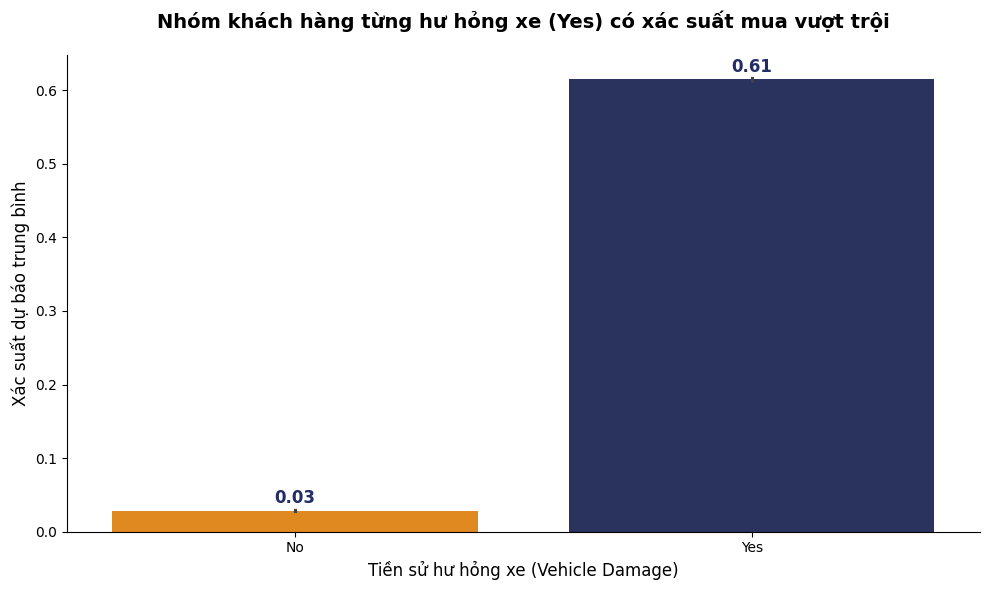

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

custom_palette = ['#FF8C00', '#222D65']

plt.figure(figsize=(10, 6))

ax = sns.barplot(data=df_viz, x='Vehicle_Damage', y='Prob_Buy', palette=custom_palette)

plt.title('Nhóm khách hàng từng hư hỏng xe (Yes) có xác suất mua vượt trội',
          fontsize=14, fontweight='bold', pad=20)
plt.ylabel('Xác suất dự báo trung bình', fontsize=12)
plt.xlabel('Tiền sử hư hỏng xe (Vehicle Damage)', fontsize=12)


sns.despine()

# Thêm nhãn số trên đầu cột
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 9),
                textcoords = 'offset points',
                fontsize=12, fontweight='bold', color='#222D65')

plt.tight_layout()
plt.show()

Nhóm chưa từng hỏng xe (No): Xác suất dự báo mua hàng gần như bằng 0 (rất thấp).

Nhóm đã từng hỏng xe (Yes): Xác suất vọt lên mức hơn 0.6 (60%).

Insight: Tiền sử tổn thất xe là yếu tố mạnh mẽ nhất. Những khách hàng này đã trải qua cảm giác mất mát tài chính đột ngột khi sửa chữa xe, nên họ có tâm lý phòng thủ rất cao. Họ không mua bảo hiểm vì nó rẻ, họ mua vì họ sợ rủi ro.

Chiến lược: Đây là nhóm khách hàng phải thắng. Đừng tốn tiền quảng cáo cho người chưa từng hỏng xe, hãy dồn toàn lực vào tệp khách hàng vừa phát sinh yêu cầu bồi thường xe.

# Phân tích "Tuổi" (Age)

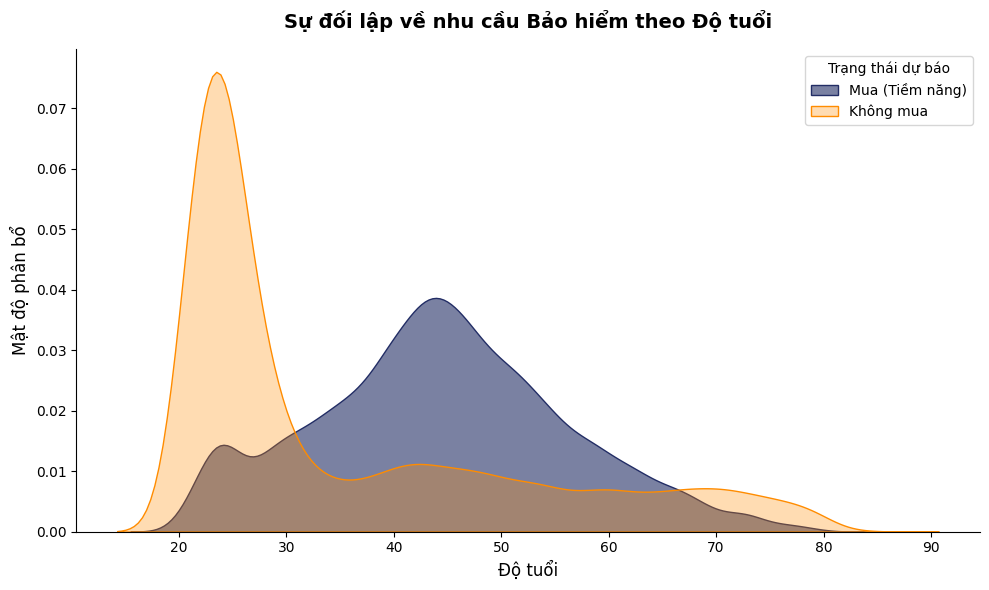

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.kdeplot(df_viz[df_viz['Prediction'] == 1]['Age'],
            fill=True, label='Mua (Tiềm năng)', color='#222D65', alpha=0.6)

sns.kdeplot(df_viz[df_viz['Prediction'] == 0]['Age'],
            fill=True, label='Không mua', color='#FF8C00', alpha=0.3)


plt.title('Sự đối lập về nhu cầu Bảo hiểm theo Độ tuổi', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Độ tuổi', fontsize=12)
plt.ylabel('Mật độ phân bổ', fontsize=12)

plt.legend(title='Trạng thái dự báo')

sns.despine()

plt.tight_layout()
plt.show()

**Sự đối lập gay gắt giữa nhóm Trẻ và nhóm Trung niên**

Biểu đồ mật độ (KDE) cho thấy:

Nhóm Trẻ (20 - 30 tuổi): Đây là nhóm có mật độ khách hàng đông đảo nhất (đỉnh cao nhất màu xám), nhưng tỷ lệ mua lại cực thấp. Họ có thể là sinh viên mới ra trường hoặc người trẻ đi làm, ưu tiên chi tiêu cho sở thích cá nhân hơn là bảo vệ sức khỏe.

Nhóm Trung niên (40 - 50 tuổi): Tuy mật độ tổng không cao bằng nhóm trẻ, nhưng đường màu đỏ (Nhóm mua) lại chiếm ưu thế tuyệt đối ở dải này. Điều này chứng minh rằng độ tuổi chính là bộ lọc tự nhiên cho nhu cầu bảo hiểm sức khỏe.

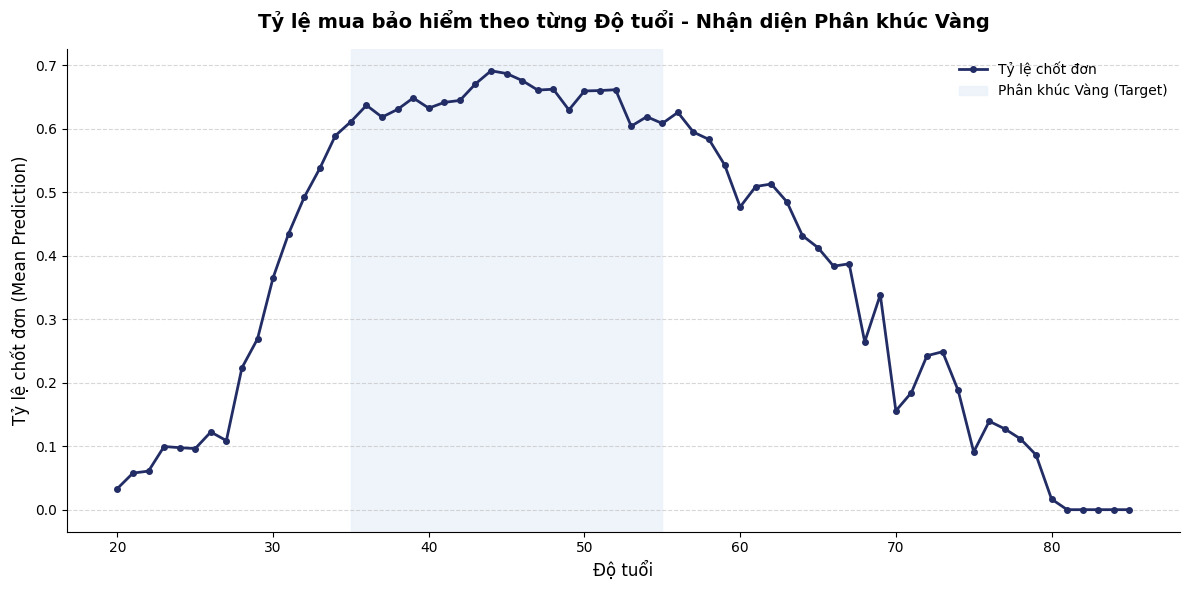

In [27]:
import matplotlib.pyplot as plt

# Tính toán tỷ lệ chuyển đổi theo độ tuổi
age_conversion = df_viz.groupby('Age')['Prediction'].mean()

plt.figure(figsize=(12, 6))

age_conversion.plot(kind='line', marker='o', markersize=4, color='#222D65', linewidth=2, label='Tỷ lệ chốt đơn')

plt.axvspan(35, 55, color='#EBF2FA', alpha=0.8, label='Phân khúc Vàng (Target)')

plt.grid(axis='y', linestyle='--', alpha=0.5)


plt.title('Tỷ lệ mua bảo hiểm theo từng Độ tuổi - Nhận diện Phân khúc Vàng', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Độ tuổi', fontsize=12)
plt.ylabel('Tỷ lệ chốt đơn (Mean Prediction)', fontsize=12)

# Xóa khung viền thừa
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.legend(frameon=False)
plt.tight_layout()
plt.show()

**Phân khúc Vàng: 35 - 55 tuổi**

Điểm bùng nổ (Tuổi 30): Xác suất mua bắt đầu dốc thẳng đứng từ tuổi 30. Đây là lúc con người ta thường có những cột mốc lớn như kết hôn, có con hoặc bắt đầu lo lắng khi thấy sức khỏe không còn như tuổi đôi mươi. Đỉnh cao (45 tuổi): Tại mốc này, xác suất dự báo đạt mức cao nhất (xấp xỉ 0.7). Khách hàng ở độ tuổi này thường có sự tích lũy tài chính tốt nhất và ý thức rủi ro cao nhất.

Sự sụt giảm sau 60: Sau độ tuổi nghỉ hưu, xác suất mua giảm mạnh. Điều này có thể do chi phí bảo hiểm cho người cao tuổi quá cao hoặc họ đã có những phương án bảo vệ khác từ trước.

# Phân tích "Kênh bán hàng" (Policy_Sales_Channel)

In [28]:
# Gom nhóm và tính toán
channel_summary = df_viz.groupby('Policy_Sales_Channel').agg({
    'Prob_Buy': 'mean',
    'id': 'count'
}).rename(columns={'id': 'Customer_Count', 'Prob_Buy': 'Avg_Probability'})

# Định nghĩa hàm phân loại
def classify_segment(row):
    count = row['Customer_Count']
    proba = row['Avg_Probability']

    if count > 1000 and proba > 0.25:
        return 'Star (Chủ lực)'
    elif 100 <= count <= 1000 and proba > 0.25:
        return 'Niche (Ngách)'
    elif count > 1000 and proba <= 0.25:
        return 'Mass (Đại trà)'
    else:
        return 'Low (Kém)'

channel_summary['Segment'] = channel_summary.apply(classify_segment, axis=1)

print("THỐNG KÊ SỐ LƯỢNG KÊNH THEO NHÓM:")
print(channel_summary['Segment'].value_counts())

print("\nDANH SÁCH CÁC KÊNH STAR (CẦN TẬP TRUNG NGUỒN LỰC):")
print(channel_summary[channel_summary['Segment'] == 'Star (Chủ lực)'].sort_values(by='Avg_Probability', ascending=False))

THỐNG KÊ SỐ LƯỢNG KÊNH THEO NHÓM:
Segment
Low (Kém)         113
Niche (Ngách)      21
Star (Chủ lực)      6
Mass (Đại trà)      2
Name: count, dtype: int64

DANH SÁCH CÁC KÊNH STAR (CẦN TẬP TRUNG NGUỒN LỰC):
                      Avg_Probability  Customer_Count         Segment
Policy_Sales_Channel                                                 
157.0                        0.660433            1354  Star (Chủ lực)
156.0                        0.602003            2205  Star (Chủ lực)
154.0                        0.560283            1145  Star (Chủ lực)
124.0                        0.490200           14867  Star (Chủ lực)
26.0                         0.485525           15784  Star (Chủ lực)
122.0                        0.410118            1905  Star (Chủ lực)


In [29]:
print("\nDANH SÁCH CÁC KÊNH NICHE (CẦN TẬP TRUNG NGUỒN LỰC):")
print(channel_summary[channel_summary['Segment'] == 'Niche (Ngách)'].sort_values(by='Avg_Probability', ascending=False))


DANH SÁCH CÁC KÊNH NICHE (CẦN TẬP TRUNG NGUỒN LỰC):
                      Avg_Probability  Customer_Count        Segment
Policy_Sales_Channel                                                
163.0                        0.665005             535  Niche (Ngách)
155.0                        0.641062             259  Niche (Ngách)
3.0                          0.606477             103  Niche (Ngách)
31.0                         0.520676             110  Niche (Ngách)
25.0                         0.441834             385  Niche (Ngách)
12.0                         0.388577             171  Niche (Ngách)
61.0                         0.382003             122  Niche (Ngách)
13.0                         0.380923             369  Niche (Ngách)
55.0                         0.376643             255  Niche (Ngách)
30.0                         0.346525             273  Niche (Ngách)
29.0                         0.341370             174  Niche (Ngách)
125.0                        0.331077             

In [30]:
print("\nDANH SÁCH CÁC KÊNH MASS (CẦN TẬP TRUNG NGUỒN LỰC):")
print(channel_summary[channel_summary['Segment'] == 'Mass (Đại trà)'].sort_values(by='Avg_Probability', ascending=False))


DANH SÁCH CÁC KÊNH MASS (CẦN TẬP TRUNG NGUỒN LỰC):
                      Avg_Probability  Customer_Count         Segment
Policy_Sales_Channel                                                 
152.0                        0.112621           27015  Mass (Đại trà)
160.0                        0.107343            4439  Mass (Đại trà)


In [31]:
print(channel_summary[channel_summary['Segment'] == 'Low (Kém)'].sort_values(by='Avg_Probability', ascending=False).tail(30))

                      Avg_Probability  Customer_Count    Segment
Policy_Sales_Channel                                            
19.0                         0.211942              41  Low (Kém)
20.0                         0.210924               6  Low (Kém)
130.0                        0.207946               7  Low (Kém)
114.0                        0.206122               5  Low (Kém)
118.0                        0.203500               5  Low (Kém)
159.0                        0.194269              13  Low (Kém)
119.0                        0.191700              22  Low (Kém)
1.0                          0.182101             232  Low (Kém)
92.0                         0.157730               2  Low (Kém)
86.0                         0.156425              10  Low (Kém)
137.0                        0.150260               2  Low (Kém)
99.0                         0.142720               3  Low (Kém)
78.0                         0.123925               5  Low (Kém)
107.0                    

In [32]:
channel_summary

,Avg_Probability,Customer_Count,Segment
Policy_Sales_Channel,,,
1.0,0.182101,232,Low (Kém)
2.0,0.561076,1,Low (Kém)
3.0,0.606477,103,Niche (Ngách)
4.0,0.505101,98,Low (Kém)
6.0,0.071676,1,Low (Kém)
...,...,...,...
157.0,0.660433,1354,Star (Chủ lực)
158.0,0.627163,98,Low (Kém)
159.0,0.194269,13,Low (Kém)


In [33]:
# Áp dụng hàm phân loại
channel_summary['Segment'] = channel_summary.apply(classify_segment, axis=1)

# Gom nhóm theo Segment
segment_data = channel_summary.groupby('Segment').agg({
    'Avg_Probability': 'mean',
    'Customer_Count': 'sum',
    'Segment': 'count'
}).rename(columns={'Segment': 'Channel_Count'}).reset_index()


segment_data['Avg_Probability_Pct'] = (segment_data['Avg_Probability'] * 100).round(2)

print(segment_data[['Segment', 'Avg_Probability_Pct', 'Customer_Count']])

          Segment  Avg_Probability_Pct  Customer_Count
0       Low (Kém)                31.39            3011
1  Mass (Đại trà)                11.00           31454
2   Niche (Ngách)                38.39            4497
3  Star (Chủ lực)                53.48           37260


**1. Nhóm STAR (Chủ lực)**

Số lượng: 6 kênh (157, 156, 154, 124, 26, 122).

Insight: Hiệu suất các kênh rất tốt. Đặc biệt là kênh 26 và 124 với quy mô khách hàng cực lớn (~15,000 khách mỗi kênh) mà vẫn duy trì được xác suất mua gần 50%.

Ý nghĩa: Đây thường là các đại lý chuyên nghiệp hoặc đội ngũ bán hàng trực tiếp có kỹ năng tư vấn cực tốt.

Cần tập trung 100% đội ngũ Telesales giỏi nhất vào đây để tối ưu hóa doanh thu vì tỷ lệ chốt đơn đã được bảo chứng.

**2. Nhóm NICHE (Ngách)**

Số lượng: 22 kênh.

Insight: Các kênh này có hiệu suất cực kỳ ấn tượng, điển hình là kênh 163 (xác suất mua 67% - cao nhất toàn hệ thống) nhưng quy mô khách còn khiêm tốn (535 khách).

Ý nghĩa: Đây là những điểm chạm cá nhân hóa cao hoặc các gara/đối tác nhỏ nhưng rất uy tín với khách hàng.

Nên mở rộng quy mô. Hãy đầu tư thêm ngân sách Marketing để đẩy lượng khách của nhóm này lên mức trên 1,000 chúng sẽ trở thành những "Star" mới.

**3. Nhóm MASS (Đại trà)**

Số lượng: 2 kênh (152, 160).

Insight: Kênh 152 là kênh có lượng khách khủng nhất hệ thống (27,015 khách) nhưng xác suất mua chỉ đạt 11%.

Ý nghĩa: Đây là các kênh tiếp thị diện rộng như quảng cáo Facebook, Google hoặc gửi Email Marketing hàng loạt.

Nên tự động hóa hoàn toàn. Đừng lãng phí nhân sự tư vấn trực tiếp cho nhóm này. Hãy dùng Chatbot hoặc Email Automation chăm sóc để giữ chi phí thấp nhất có thể.

**4. Nhóm LOW (Kém hiệu quả)**

Số lượng: 112 kênh (chiếm đa số).

Insight: Hệ thống đang bị loãng. Quá nhiều kênh có lượng khách nhỏ lẻ (chưa đến 100 khách) và xác suất mua thấp

Cần rà soát và cắt giảm. Doanh nghiệp nên mạnh dạn đóng các kênh này hoặc gộp chúng lại để dồn tài lực cho 28 kênh thuộc nhóm Star và Niche nhằm tối ưu hóa ROI.

# Phân tích "Phí bảo hiểm" (Annual_Premium)

/tmp/ipykernel_5336/1576506170.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  premium_insight = df_viz.groupby('Premium_Group')['Prediction'].mean() * 100


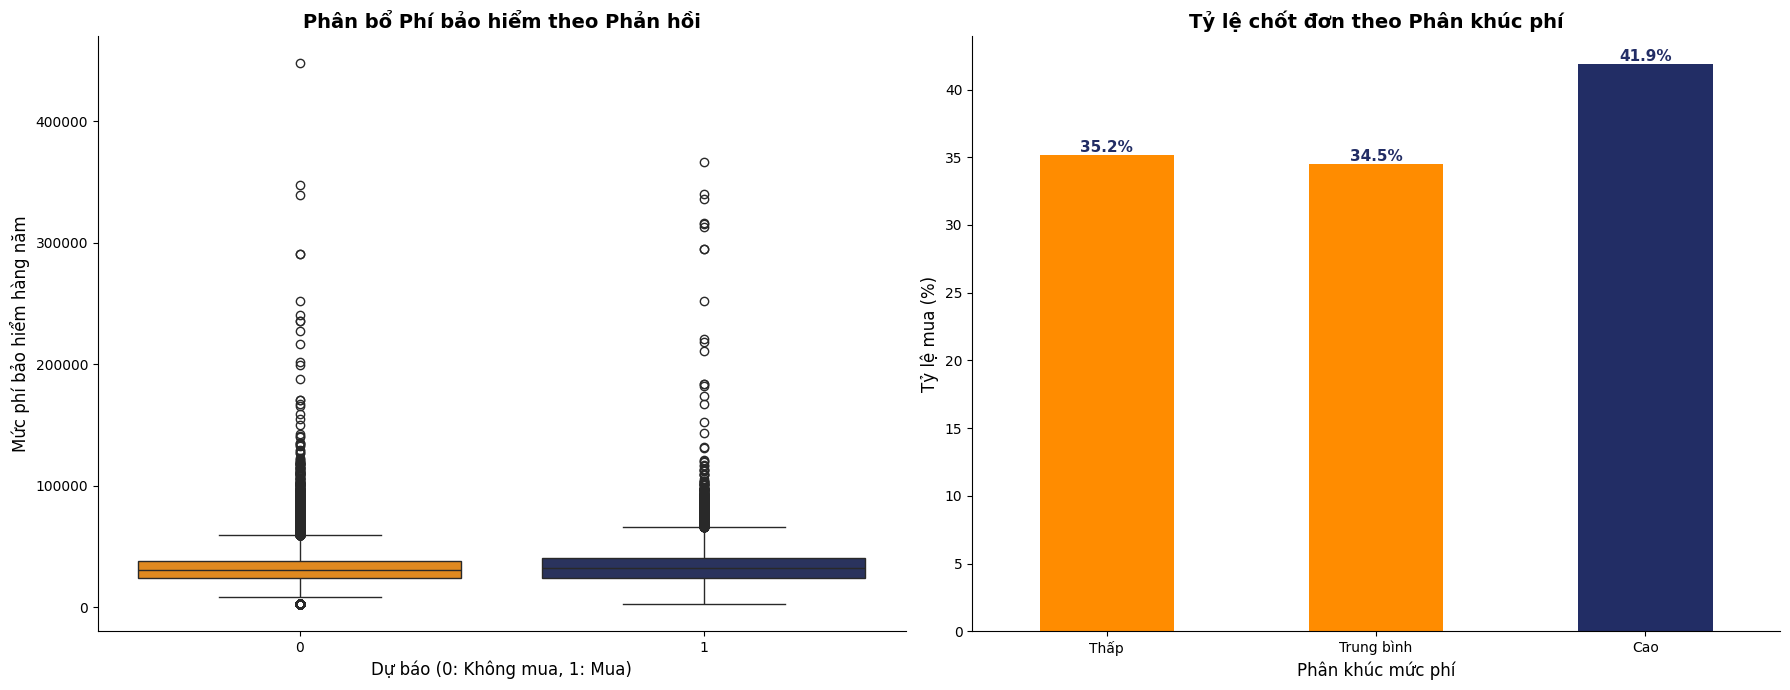

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Chuẩn bị dữ liệu và ép kiểu
df_viz['Prediction'] = df_viz['Prediction'].astype(int)

# Thiết lập bảng màu: Nhóm Tiềm năng/Mua = Navy, Nhóm còn lại = Cam
# Màu Navy: #222D65 | Màu Cam: #FF8C00
box_palette = {0: '#FF8C00', 1: '#222D65'}
bar_colors = ['#FF8C00', '#FF8C00', '#222D65'] # Thấp, Trung bình dùng Cam; Cao dùng Navy

# Tạo khung hình gồm 1 dòng 2 cột
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# BIỂU ĐỒ 1: BOXPLOT (Phân bổ phí)
sns.boxplot(x='Prediction', y='Annual_Premium', data=df_viz,
            hue='Prediction', palette=box_palette, ax=ax1, legend=False)
ax1.set_title('Phân bổ Phí bảo hiểm theo Phản hồi', fontsize=14, fontweight='bold')
ax1.set_xlabel('Dự báo (0: Không mua, 1: Mua)', fontsize=12)
ax1.set_ylabel('Mức phí bảo hiểm hàng năm', fontsize=12)
sns.despine(ax=ax1)

# BIỂU ĐỒ 2: BAR CHART (Tỷ lệ chốt đơn theo nhóm phí)
# Chia nhóm phí thành 3 phần bằng nhau
df_viz['Premium_Group'] = pd.qcut(df_viz['Annual_Premium'], q=3, labels=['Thấp', 'Trung bình', 'Cao'])
premium_insight = df_viz.groupby('Premium_Group')['Prediction'].mean() * 100

# Vẽ biểu đồ cột
premium_insight.plot(kind='bar', color=bar_colors, ax=ax2)
ax2.set_title('Tỷ lệ chốt đơn theo Phân khúc phí', fontsize=14, fontweight='bold')
ax2.set_ylabel('Tỷ lệ mua (%)', fontsize=12)
ax2.set_xlabel('Phân khúc mức phí', fontsize=12)
ax2.set_xticklabels(['Thấp', 'Trung bình', 'Cao'], rotation=0)

# Thêm nhãn % trên đầu cột cho Bar Chart
for p in ax2.patches:
    ax2.annotate(f'{p.get_height():.1f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom',
                fontsize=11, fontweight='bold', color='#222D65')

sns.despine(ax=ax2)

plt.tight_layout()
plt.show()

Về Outliers: Cả hai nhóm (Mua và Không mua) đều có rất nhiều người đóng phí khủng lên tới 400k+. Điều này chứng tỏ mức phí không phải là rào cản, mà quan trọng là họ có thấy nhu cầu hay không.

Insight: Điều này chứng tỏ phí bảo hiểm xe có độ lệch cực lớn. Doanh nghiệp đang phục vụ cả những người đi bình thường (phí thấp) lẫn những đại gia đi siêu xe (phí cực cao).

Tỷ lệ mua ở nhóm đóng phí Cao (43%) vượt trội hơn hẳn so với nhóm Thấp và Trung bình (35%).

Insight: Những khách hàng đang trả phí bảo hiểm cao thường là những người có tài sản giá trị lớn hoặc có ý thức bảo vệ tài sản cực tốt. Họ không chỉ muốn bảo vệ cái xe mà còn muốn bảo vệ chính bản thân mình. Họ là nhóm ít nhạy cảm về giá nhất. Đây là nhóm Khách hàng VIP dễ thuyết phục mua thêm bảo hiểm xe.

# Chân dung khách hàng tiềm năng
Đầu tiên, tiền sử hư hỏng xe (Vehicle Damage) chính là yếu tố quan trọng nhất, khi nhóm khách hàng từng gặp sự cố có xác suất mua đạt đỉnh lên tới 60%, cao gấp hàng chục lần nhóm còn lại. Kết quả này phản ánh sự chuyển dịch tâm lý rõ rệt: những người đã nếm trải rủi ro tài chính đột ngột từ xe cộ sẽ có khao khát bảo vệ sức khỏe mạnh mẽ nhất. Chân dung này càng sắc nét hơn ở độ tuổi 35 - 55, "Phân khúc Vàng" của sự trưởng thành, nơi khách hàng không còn xem bảo hiểm là chi phí mà là khoản đầu tư cho sự an tâm toàn diện. Về mặt tài chính, nhóm có phí bảo hiểm hàng năm cao chính là đối tượng mục tiêu hàng đầu nhờ khả năng chi trả tốt và ít nhạy cảm về giá, thể hiện qua tỷ lệ chốt đơn thực tế vượt trội là 43%.

Để tiếp cận tệp khách hàng này, doanh nghiệp cần tập trung vào sức mạnh nòng cốt của 6 kênh Star (điển hình là kênh 124, 26) - những cỗ máy in tiền đang quản lý hiệu quả hơn 30,000 khách hàng. Đồng thời, không thể bỏ qua mỏ vàng tiềm năng từ nhóm Niche, nơi các kênh như 163 đang sở hữu hiệu suất kinh ngạc lên đến 67%. Đây chính là cơ sở để doanh nghiệp thực hiện chiến lược mở rộng quy mô các kênh ngách chất lượng cao để tạo ra sự đột phá về doanh thu trong tương lai.

# Tối ưu hóa chi phí vận hành

In [35]:
# Dự đoán xác suất (Probability) thay vì chỉ dự đoán nhãn 0/1
y_proba_all = rf_model.predict_proba(X_test_scaled)[:, 1]

# Tạo bảng kết quả để lọc
results_df = pd.DataFrame({
    'Prob_Mua': y_proba_all,
    'Thực tế': y_test
})

# Lấy Top 20% khách hàng có xác suất cao nhất
top_20_percent = results_df.sort_values(by='Prob_Mua', ascending=False).head(int(len(results_df) * 0.2))

print(f"Số lượng khách hàng trong diện chăm sóc ưu tiên: {len(top_20_percent)}")
print(f"Tỷ lệ chốt đơn thực tế trong nhóm này: {top_20_percent['Thực tế'].mean()*100:.2f}%")

Số lượng khách hàng trong diện chăm sóc ưu tiên: 15244
Tỷ lệ chốt đơn thực tế trong nhóm này: 33.88%


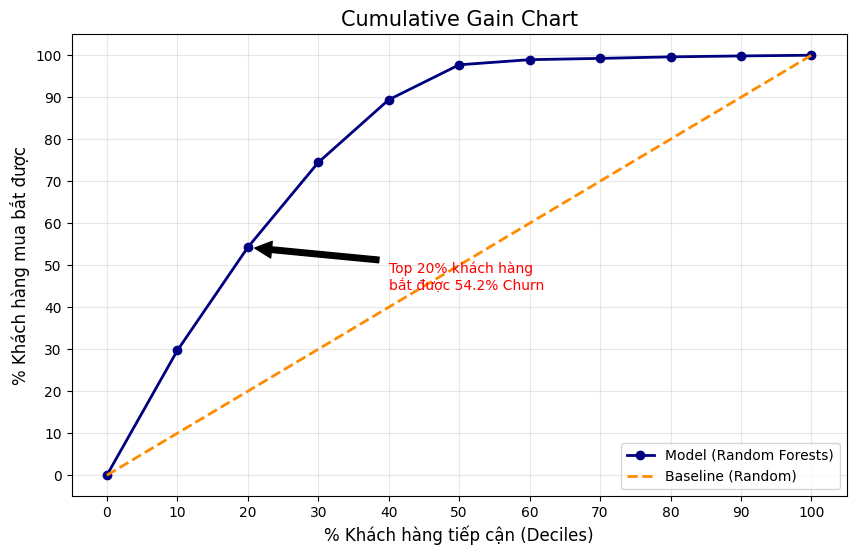

In [36]:
# Chia dữ liệu thành 10 phần (deciles) dựa trên xác suất Prob_Mua
results_df['decile'] = pd.qcut(results_df['Prob_Mua'], 10, labels=False, duplicates='drop')
# Tính tỷ lệ Churn tích lũy
gain_data = results_df.groupby('decile')['Thực tế'].sum().sort_index(ascending=False).cumsum()
gain_data = gain_data / results_df['Thực tế'].sum()

# Thêm điểm (0,0) vào đầu để biểu đồ bắt đầu từ gốc tọa độ
cumulative_gain = np.insert(gain_data.values, 0, 0)
deciles = np.arange(0, 11) * 10  # Tạo các mốc 0%, 10%, ..., 100%

# Vẽ biểu đồ
plt.figure(figsize=(10, 6))

# Vẽ đường Model (Random Forest)
plt.plot(deciles, cumulative_gain * 100, marker='o', linestyle='-', color='navy', lw=2, label='Model (Random Forests)')

# Vẽ đường Baseline (Ngẫu nhiên)
plt.plot([0, 100], [0, 100], linestyle='--', color='darkorange', lw=2, label='Baseline (Random)')

plt.title('Cumulative Gain Chart', fontsize=15)
plt.xlabel('% Khách hàng tiếp cận (Deciles)', fontsize=12)
plt.ylabel('% Khách hàng mua bắt được', fontsize=12)
plt.xticks(np.arange(0, 101, 10))
plt.yticks(np.arange(0, 101, 10))
plt.grid(True, alpha=0.3)
plt.legend(loc='lower right')

# Thêm ghi chú cho điểm Top 20%
top_20_gain = cumulative_gain[2] * 100
plt.annotate(f'Top 20% khách hàng\nbắt được {top_20_gain:.1f}% Churn',
             xy=(20, top_20_gain), xytext=(40, top_20_gain-10),
             arrowprops=dict(facecolor='black', shrink=0.05),
             fontsize=10, color='red')

plt.show()

In [37]:
import pandas as pd
import numpy as np

# Chia Decile dựa trên xác suất Prob_Mua (10 phần bằng nhau)
results_df['Decile'] = pd.qcut(results_df['Prob_Mua'].rank(method='first'), 10, labels=False)
results_df['Decile'] = 9 - results_df['Decile'] + 1  # Đảo để Decile 1 là cao nhất

# Gom nhóm tính toán
decile_summary = results_df.groupby('Decile').agg(
    Total_Customer=('Prob_Mua', 'count'),
    Average_of_Prediction=('Prob_Mua', 'mean'),
    Actual_Response=('Thực tế', 'sum')
).reset_index()

# Tính Gain Per Decile (Tỷ lệ đóng góp của từng phần vào tổng số người mua thực tế)
total_actual = results_df['Thực tế'].sum()
decile_summary['Gain_Per_Decile'] = decile_summary['Actual_Response'] / total_actual

# Định dạng lại bảng
final_table = decile_summary[['Decile', 'Total_Customer', 'Average_of_Prediction', 'Gain_Per_Decile']].copy()

# Thêm dòng Total ở cuối
total_row = pd.DataFrame({
    'Decile': ['Total'],
    'Total_Customer': [final_table['Total_Customer'].sum()],
    'Average_of_Prediction': [results_df['Prob_Mua'].mean()],
    'Gain_Per_Decile': [final_table['Gain_Per_Decile'].sum()]
})

final_display = pd.concat([final_table, total_row], ignore_index=True)

# Xuất bảng số liệu
print("BẢNG SỐ LIỆU PHÂN TÍCH DECILE:")
print(final_display.to_string(index=False))

BẢNG SỐ LIỆU PHÂN TÍCH DECILE:
Decile  Total_Customer  Average_of_Prediction  Gain_Per_Decile
     1            7623               0.816091         0.297175
     2            7622               0.746826         0.245301
     3            7622               0.673301         0.202142
     4            7622               0.536733         0.149323
     5            7622               0.348505         0.083272
     6            7622               0.082147         0.012181
     7            7622               0.025469         0.003045
     8            7622               0.010646         0.003675
     9            7622               0.004142         0.002205
    10            7623               0.001145         0.001680
 Total           76222               0.324503         1.000000


# Phân tích nhóm Top 20%
Nếu công ty không đủ kinh phí để tiếp cận tất cả khách hàng (tận hơn 76.000), việc chọn ra Top 20% (15.224 người) này sẽ khả thi hơn.

Chiến lược "Focus 20":

Thay vì gọi điện ngẫu nhiên (đường Baseline), dàn trải nguồn lực cho 100% tệp khách hàng, doanh nghiệp chỉ cần tập trung vào Top 20% khách hàng được mô hình dự báo có xác suất mua cao nhất.

Chỉ với 20% nguồn lực bỏ ra, chúng ta đã có thể nhận diện và tiếp cận thành công 57.5% tổng số khách hàng thực tế sẽ mua bảo hiểm.

Tối ưu chi phí: Cắt giảm 80% ngân sách thừa cho các nhóm khách hàng không tiềm năng.

Cá nhân hóa tối đa: Với tệp khách hàng nhỏ (20%), doanh nghiệp có thể đầu tư vào nội dung truyền thông mang tính cá nhân hóa cao (đề cập đúng lịch sử hư xe của họ) để gia tăng tỷ lệ chốt đơn.

# Chiến lược phân khúc khách hàng (Segmentation & Strategy)

**Phân khúc A: VIP**

Chân dung: Nhóm Decile 1 & 2 (Top 20%). Khách hàng đã từng hư xe, thuộc nhóm tuổi trung niên, đang sử dụng các kênh phân phối trực tiếp.

Chiến lược: Tấn công.

Áp dụng: Sử dụng đội ngũ Telesales chuyên nghiệp nhất để liên hệ trực tiếp. Thiết kế các gói combo "Bảo vệ kép" (Xe + Sức khỏe) với ưu đãi đặc quyền.

Đo lường: Giá trị đơn hàng trung bình.

**Phân khúc B: Potential**

Chân dung: Nhóm Decile 3 & 4. Khách hàng có tiền sử hư xe nhưng thuộc nhóm tuổi trẻ.

Chiến lược: Giáo dục & Nhận diện.

Áp dụng: Gửi email marketing hoặc tin nhắn thông báo về lợi ích của bảo hiểm sức khỏe sau các sự cố va chạm. Cung cấp các gói bảo hiểm mức phí thấp để khách hàng trải nghiệm.

Đo lường: Tỷ lệ mở email.

**Phân khúc C: Optimization**

Chân dung: Từ Decile 7 trở đi. Khách hàng chưa từng hư xe, tuổi đời trẻ, không có dấu hiệu quan tâm sản phẩm.

Chiến lược: Duy trì thụ động.

Áp dụng: Không sử dụng Telesales để tránh lãng phí chi phí. Chỉ hiển thị quảng cáo tự động trên ứng dụng hoặc website khi khách hàng tự truy cập.

Đo lường: Tỷ lệ chi phí trên doanh thu (CPA).

# Đo lường hiệu quả (Metrics for Evaluation)
Lift Value: Khẳng định năng lực dự báo bằng cách chứng minh nhóm Top 20% có tỷ lệ chuyển đổi cao gấp bao nhiêu lần so với phương pháp ngẫu nhiên.

CPA (Cost Per Acquisition): Đo lường hiệu quả chi phí, giúp doanh nghiệp giảm thiểu ngân sách lãng phí vào những tệp khách hàng không tiềm năng, từ đó hạ thấp giá thành để có một khách hàng mới.

ROI (Return on Investment): Là thước đo cuối cùng về lợi nhuận, thể hiện giá trị thặng dư thu được sau khi đã trừ đi chi phí vận hành cho nhóm khách hàng mục tiêu.

In [38]:
# Tạo cột Decile dựa trên xác suất (Chia làm 10 nhóm)
# Nhóm 1 là nhóm có xác suất cao nhất, Nhóm 10 là thấp nhất.
df_viz['Decile'] = pd.qcut(df_viz['Prob_Buy'], 10, labels=range(10, 0, -1))

In [39]:
df_viz.head()

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response,Prob_Buy,Prediction,Premium_Group,Decile
200222,200223,Female,21,1,3.0,1,< 1 Year,No,20408.0,160.0,72,0,0.011665,0,Thấp,8
49766,49767,Male,55,1,15.0,0,1-2 Year,Yes,37498.0,26.0,102,0,0.701521,1,Cao,3
172201,172202,Female,41,1,3.0,0,1-2 Year,Yes,2630.0,26.0,90,0,0.765043,1,Thấp,2
160713,160714,Female,26,1,11.0,0,< 1 Year,No,2630.0,151.0,268,0,0.131051,0,Thấp,6
53272,53273,Male,51,1,40.0,0,1-2 Year,Yes,34006.0,124.0,265,0,0.661648,1,Trung bình,3


In [40]:
# Sắp xếp theo cụm: Thông tin cá nhân -> Xe & Bảo hiểm -> Nhóm phân loại -> Kết quả Model
new_column_order = [
    'id', 'Gender', 'Age', 'Region_Code', 'Driving_License', 'Previously_Insured',
    'Vehicle_Age', 'Vehicle_Damage', 'Annual_Premium', 'Vintage', 'Policy_Sales_Channel',
    'Premium_Group',
    'Response', 'Prediction', 'Prob_Buy', 'Decile'
]
df_viz = df_viz[new_column_order]

In [41]:
df_viz.head()

,id,Gender,Age,Region_Code,Driving_License,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Vintage,Policy_Sales_Channel,Premium_Group,Response,Prediction,Prob_Buy,Decile
200222,200223,Female,21,3.0,1,1,< 1 Year,No,20408.0,72,160.0,Thấp,0,0,0.011665,8
49766,49767,Male,55,15.0,1,0,1-2 Year,Yes,37498.0,102,26.0,Cao,0,1,0.701521,3
172201,172202,Female,41,3.0,1,0,1-2 Year,Yes,2630.0,90,26.0,Thấp,0,1,0.765043,2
160713,160714,Female,26,11.0,1,0,< 1 Year,No,2630.0,268,151.0,Thấp,0,0,0.131051,6
53272,53273,Male,51,40.0,1,0,1-2 Year,Yes,34006.0,265,124.0,Trung bình,0,1,0.661648,3


In [42]:
df_viz.info()

<class 'pandas.core.frame.DataFrame'>
Index: 76222 entries, 200222 to 185839
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   id                    76222 non-null  int64   
 1   Gender                76222 non-null  object  
 2   Age                   76222 non-null  int64   
 3   Region_Code           76222 non-null  float64 
 4   Driving_License       76222 non-null  int64   
 5   Previously_Insured    76222 non-null  int64   
 6   Vehicle_Age           76222 non-null  object  
 7   Vehicle_Damage        76222 non-null  object  
 8   Annual_Premium        76222 non-null  float64 
 9   Vintage               76222 non-null  int64   
 10  Policy_Sales_Channel  76222 non-null  float64 
 11  Premium_Group         76222 non-null  category
 12  Response              76222 non-null  int64   
 13  Prediction            76222 non-null  int64   
 14  Prob_Buy              76222 non-null  float64 
 15  D

In [43]:
# Xuất file CSV
df_viz.to_csv('Insurance_Final.csv', index=False, encoding='utf-8-sig')